<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>



#### Import the required libraries we need for the lab.


In [1]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

In [3]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

#### Read the dataset in the csv file from the URL


In [4]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [5]:
boston_df=pd.read_csv(boston_url)

#### Add your code below following the instructions given in the course to complete the peer graded assignment


Is there a significant difference in the median value of houses bounded by the Charles river or not?

Is there a difference in median values of houses of each proportion of owner-occupied units built before 1940?

Can we conclude that there is no relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town?

What is the impact of an additional weighted distance to the five Boston employment centres on the median value of owner-occupied homes?

In [5]:
list(boston_df)
boston_df.CHAS.replace((1, 0), ("yes", "no"), inplace=True)
boston_df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,no,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,no,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,no,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,no,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,no,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


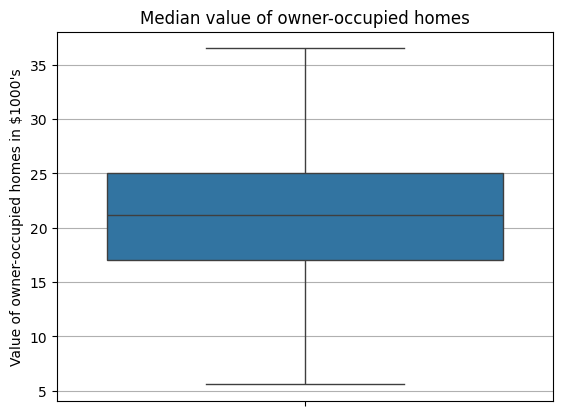

In [21]:
owner_occupied_chart = sns.boxplot(y = "MEDV", data = boston_df, showfliers = False)
owner_occupied_chart.set_title("Median value of owner-occupied homes")
owner_occupied_chart.set_ylabel("Value of owner-occupied homes in $1000's")
pyplot.grid(True, axis = "y")

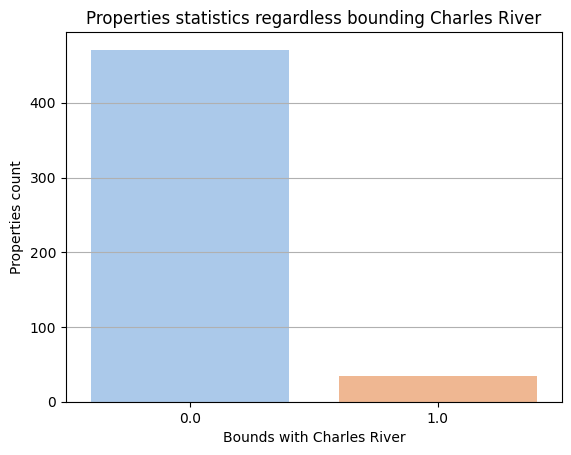

In [20]:
ch_river_chart = sns.countplot(x = "CHAS", palette = "pastel", data = boston_df, dodge=False)
ch_river_chart.set_title("Properties statistics regardless bounding Charles River")
ch_river_chart.set_ylabel("Properties count")
ch_river_chart.set_xlabel("Bounds with Charles River")
pyplot.grid(True, axis = "y")

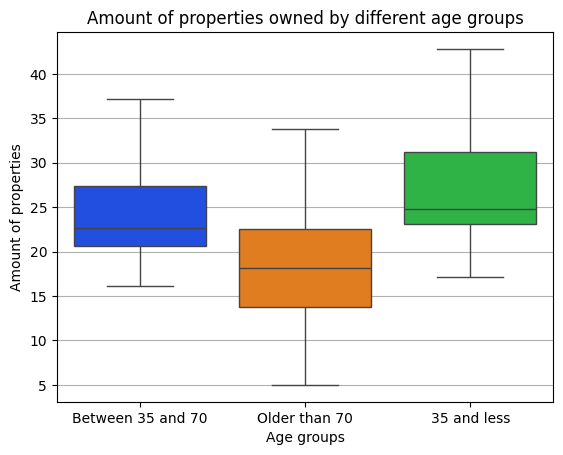

In [15]:
young_age = boston_df.loc[(boston_df["AGE"] <= 35), "age group"] = "35 and less"
mid_age = boston_df.loc[(boston_df["AGE"] > 35) & (boston_df["AGE"] < 70), "age group"] = "Between 35 and 70"
older_age = boston_df.loc[(boston_df["AGE"] >= 70), "age group"] = "Older than 70"
age_distribution_chart = sns.boxplot(data = boston_df, x = "age group", y = "MEDV", hue = "age group", palette = "bright", showfliers = False)
age_distribution_chart.set_title("Amount of properties owned by different age groups")
age_distribution_chart.set_xlabel("Age groups")
age_distribution_chart.set_ylabel("Amount of properties")
pyplot.grid(True, axis='y')

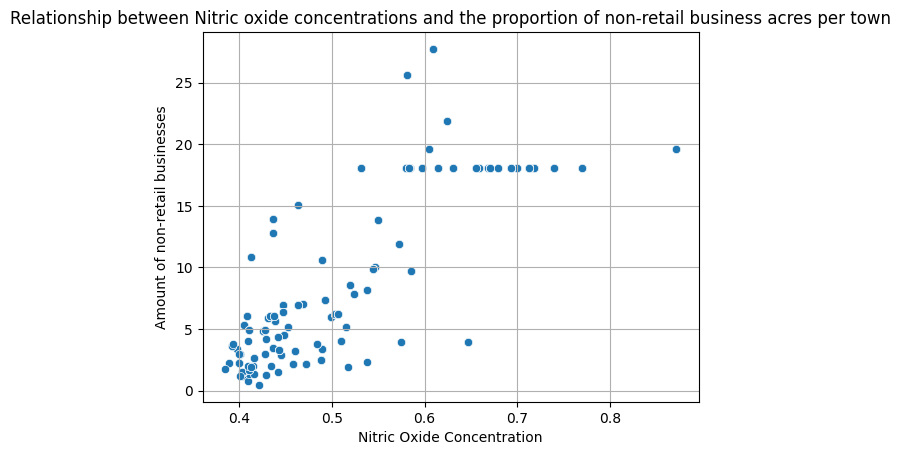

In [17]:
nio_to_business_chart = sns.scatterplot(data = boston_df, x = "NOX", y = "INDUS")
nio_to_business_chart.set_title("Relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town")
nio_to_business_chart.set_xlabel("Nitric Oxide Concentration")
nio_to_business_chart.set_ylabel("Amount of non-retail businesses")
pyplot.grid(True)

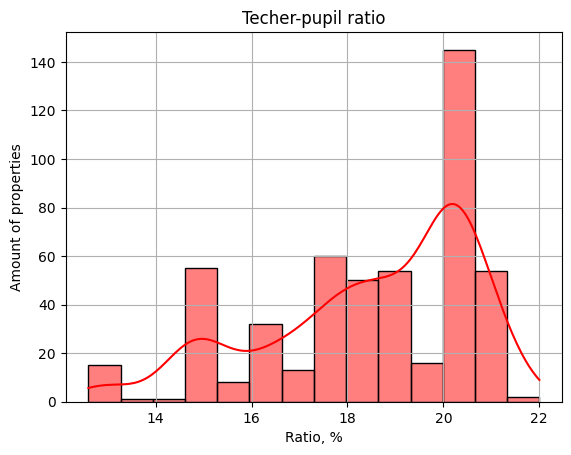

In [18]:
teacher_pupil_chart = sns.histplot(data = boston_df, x = "PTRATIO", color = "red", kde = True)
teacher_pupil_chart.set_title("Techer-pupil ratio")
teacher_pupil_chart.set_xlabel("Ratio, %")
teacher_pupil_chart.set_ylabel("Amount of properties")
pyplot.grid(True)

# Task 3: Use the appropriate tests to answer the questions provided.

### Exerise 1: Is there a significant difference in median value of houses bounded by the Charles river or not? 

H₀: Median values are the same, there is no significant difference in the median value of the houses.

Hₐ: Median values are significantly different.

α = 0.05

In [17]:
scipy.stats.ttest_ind(boston_df[boston_df["CHAS"] == "yes"]["MEDV"], boston_df[boston_df["CHAS"] == "no"]["MEDV"])

TtestResult(statistic=3.996437466090509, pvalue=7.390623170519905e-05, df=504.0)

Since pvalue <  α (0.0000739 < 0.05), we reject H0. Meaning median values are significantly different.

### Exersise 2: Is there a difference in Median values of houses (MEDV) for each proportion of owner occupied units built prior to 1940 (AGE)?

H₀: Theres no difference in median values of houses owned by diffrent age groups.

Hₐ: Theres a significant difference between values of houses owned by different age groups.

α = 0.05

In [23]:
thirty_five_lower = boston_df[boston_df["age group"] == "35 and less"]["MEDV"]
thirty_seventy = boston_df[boston_df["age group"] == "Between 35 and 70"]["MEDV"]
seventy_older = boston_df[boston_df["age group"] == "Older than 70"]["MEDV"]
scipy.stats.f_oneway(thirty_five_lower, thirty_seventy, seventy_older)

F_onewayResult(statistic=36.40764999196599, pvalue=1.7105011022702984e-15)

Since the pvalue <  α (1.71e-15 < 0.05), we reject the null hypothesis and conclude that there is a statistically significant difference in the median values of houses (MEDV) among the three age groups. This means that the proportion of owner-occupied units built before 1940 significantly affects the median house values.

### Exersise 3: Can we conclude that there is no relationship between Nitric oxide concentrations and proportion of non-retail business acres per town?

H₀: There is no relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town.

Hₐ: There is a significant relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town.

α = 0.05

In [24]:
scipy.stats.pearsonr(boston_df["NOX"], boston_df["INDUS"])

PearsonRResult(statistic=0.7636514469209192, pvalue=7.913361061210442e-98)

Since the pvalue < α (7.913e-98 < 0.05), we reject the null hypothesis and conclude next: since the correlation coeficient value is 0.76 there is a strong positive correlation between nitric oxide and proportion of non retail business acres per town

### Excersise 4: What is the impact of an additional weighted distance  to the five Boston employment centres on the median value of owner occupied homes?

H₀: An additional weighted distance to the five Boston employment centres has no impact on the median value of owner-occupied homes. In other words, the coefficient of the weighted distance variable in the regression model is zero (β = 0) 

Hₐ: An additional weighted distance to the five Boston employment centres has a significant impact on the median value of owner-occupied homes. In other words, the coefficient of the weighted distance variable in the regression model is not zero (β ≠ 0).

α = 0.05

In [28]:
x = boston_df["DIS"]
y = boston_df["MEDV"]
x = sm.add_constant(x)
model = sm.OLS(y,x).fit()
prediction = model.predict(x)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Mon, 10 Mar 2025   Prob (F-statistic):           1.21e-08
Time:                        11:57:51   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.000      16.784      19.996
DIS            1.0916      0.188      5.795      0.000       0.722       1.462
==============================================================================
Omnibus:                      139.779   Durbin-Watson:                   0.570
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              305.104
Skew:                           1.466   Prob(JB):                     5.59e-67
Kurtosis:                       5.424   Cond. No.                         9.32
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The regression analysis shows that there is a statistically significant negative relationship between the weighted distance to employment centres and the median value of owner-occupied homes, since p-value for DIS is 0.000, which is much smaller than the significance level (α = 0.05)